In [1]:
"""
SDOML v2 Dataset Construction Pipeline — IAC 2026
Probabilistic spatio-temporal forecasting of solar eruptive activity (AIA + HMI only, no EVE)

This script implements the 10-phase dataset construction plan:

| Phase | Description |
|-------|-------------|
| 1     | Raw data access (anonymous S3 → Zarr → lazy Dask) |
| 2     | Channel selection (4 AIA + 3 HMI = 7 raw channels) |
| 3     | Timestamp alignment (12-min unified timeline anchored on HMI) |
| 4     | Data cleaning (cosmic rays, gaps, disambiguation jumps, degradation, limb mask) |
| 5     | Derived scalar features (PIL length, shear, flux emergence rate); Jz/PIL/∇171 maps computed internally only, NOT stored as channels |
| 6     | Normalisation (arcsinh / tanh, training-split statistics only) |
| 7     | Label generation (GOES flares + DONKI CMEs, confined-flare flags) |
| 8     | Sliding window construction (8×12-min input, 6/12/24/48 h horizons); shards stored float16 |
| 9     | Chronological train / val / test split with leakage checks |
| 10    | Dataset validation checks |

Data sources (full stores, 2010–2020 — the _small stores only contain 2010):
  - AIA: s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/
  - HMI: s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2_hmi.zarr/

Important notes on plan corrections applied here:
  1. Plan Step 1.1 referenced sdomlv2_small.zarr — replaced by full stores (small store = 2010 only).
  2. Zarr frames are NOT guaranteed time-ordered → all alignment uses argsort(T_OBS) index maps.
  3. Spatial downsampling (area-average, flux-preserving) is applied to *physical* values BEFORE
     normalisation, so scaler statistics are computed at 256×256 working resolution.
"""

'\nSDOML v2 Dataset Construction Pipeline — IAC 2026\nProbabilistic spatio-temporal forecasting of solar eruptive activity (AIA + HMI only, no EVE)\n\nThis script implements the 10-phase dataset construction plan:\n\n| Phase | Description |\n|-------|-------------|\n| 1     | Raw data access (anonymous S3 → Zarr → lazy Dask) |\n| 2     | Channel selection (4 AIA + 3 HMI = 7 raw channels) |\n| 3     | Timestamp alignment (12-min unified timeline anchored on HMI) |\n| 4     | Data cleaning (cosmic rays, gaps, disambiguation jumps, degradation, limb mask) |\n| 5     | Derived scalar features (PIL length, shear, flux emergence rate); Jz/PIL/∇171 maps computed internally only, NOT stored as channels |\n| 6     | Normalisation (arcsinh / tanh, training-split statistics only) |\n| 7     | Label generation (GOES flares + DONKI CMEs, confined-flare flags) |\n| 8     | Sliding window construction (8×12-min input, 6/12/24/48 h horizons); shards stored float16 |\n| 9     | Chronological train / va

In [2]:
# =====================================================================
# SETUP — Install dependencies
# =====================================================================
# zarr 2.x + numcodecs pinned to match the SDOML v2 store format.
!pip install -q zarr==2.12 numcodecs==0.10.2 s3fs dask scikit-image pandas requests pyyaml huggingface_hub tqdm

  error: subprocess-exited-with-error
  
  exit code: 1
  
  [380 lines of output]
  C:\Users\SAATVIK SUMANTA\AppData\Local\Temp\pip-build-env-8xp6s34q\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
  !!
  
          ********************************************************************************
          Please consider removing the following classifiers in favor of a SPDX license expression:
  
          License :: OSI Approved :: MIT License
  
          See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
          ********************************************************************************
  
  !!
    self._finalize_license_expression()
  [numcodecs] setting up Blosc extension
  [numcodecs] compiling Blosc extension with SSE2 support
  [numcodecs] compiling Blosc extension with AVX2 support
  [numcodecs] setting up Zstandard extension
  [numcodecs] setting up LZ4 ext

In [3]:
# =====================================================================
# SETUP — Imports & global configuration
# =====================================================================
import os
import json
import warnings
import logging
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import dask.array as da
import zarr
import s3fs
import requests
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter, binary_dilation
from skimage.transform import downscale_local_mean
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger("sdoml_dataset")

C:\Users\SAATVIK SUMANTA\Desktop\IAC-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ---------------------------------------------------------------------
# Global configuration
# ---------------------------------------------------------------------
AIA_ZARR_PATH = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/"
HMI_ZARR_PATH = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2_hmi.zarr/"

YEARS = [str(y) for y in range(2010, 2021)]            # 2010–2020 inclusive

# Phase 2 — channel selection (7-channel working set: 4 AIA + 3 HMI)
AIA_CHANNELS = ["131A", "171A", "193A", "1600A"]
HMI_CHANNELS = ["Bx", "By", "Bz"]
RAW_CHANNELS = AIA_CHANNELS + HMI_CHANNELS

In [5]:
# Explicitly EXCLUDED channels (documented per plan Step 2.2):
#   94A   — poor quiet-sun SNR; marginal gain over 131A
#   211A  — largely redundant with 193A for eruption forecasting
#   304A  — chromospheric contamination dominates; unreliable filament detection
#   335A  — weakest coronal signal, poor SNR, minimal literature support
#   1700A, 4500A — photospheric; minimal coronal eruption sensitivity
#   EVE   — excluded entirely per project scope (AIA + HMI only)
EXCLUDED_CHANNELS = ["94A", "094A", "211A", "304A", "335A", "1700A", "4500A"]

In [6]:
# Phase 3 — alignment
HMI_CADENCE_MIN = 12
AIA_MATCH_TOL = pd.Timedelta(minutes=3)                 # |t_aia − t_hmi| < 3 min

# Phase 4 — cleaning
COSMIC_RAY_SIGMA = 5.0
DISAMBIG_SIGMA = 3.0
DISAMBIG_ROLL = 30                                       # rolling window (frames)
LIMB_RADIUS_FRAC = 0.98                                  # mask beyond 0.98 R_sun

# Phase 5 — derived features
MU0 = 4.0 * np.pi * 1e-7                                 # vacuum permeability
PIL_BTOTAL_THRESH = 150.0                                # Gauss, strong-field PIL
PIL_DILATE_PX = 5
HMI_PIX_AREA_CM2 = (0.000725e6 * 512 / 512) ** 2        # placeholder; refined from CDELT below

# Phase 6 — normalisation
B_SAT = 1500.0                                           # Gauss, tanh saturation
ARCSINH_A_FRAC = 0.01                                    # a = train_median * 0.01
CLIP_SIGMA = 5.0                                         # for Jz / flux-rate tails

# Phase 7 — labels
FLARE_M_THRESH = 1e-5                                    # W/m² (M1.0)
FLARE_X_THRESH = 1e-4                                    # W/m² (X1.0)
CME_FAST_KMS = 500.0
FORECAST_HORIZONS_H = [6, 12, 24, 48]

# Phase 8 — windows
T_IN = 8                                                 # input frames (96 min @ 12 min)
TARGET_SIZE = 256                                        # downsample 512 → 256
STRIDE = {"train": 1, "val": 4, "test": 6}

# Phase 9 — chronological splits
SPLITS = {
    "train": (2010, 2014),   # Cycle 24 rising + maximum
    "val":   (2015, 2017),   # Cycle 24 declining
    "test":  (2018, 2020),   # Cycle 24 minimum + Cycle 25 rising
}

# Output directory for the constructed dataset
OUT_DIR = "./sdoml_dataset_out"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Working channel set ({len(RAW_CHANNELS)}): {RAW_CHANNELS}")
print(f"Excluded: {EXCLUDED_CHANNELS} + all EVE data")

Working channel set (7): ['131A', '171A', '193A', '1600A', 'Bx', 'By', 'Bz']
Excluded: ['94A', '094A', '211A', '304A', '335A', '1700A', '4500A'] + all EVE data


In [7]:
# =====================================================================
# PHASE 1 / Step 1.1 - Connect to AWS S3 anonymously and open stores
# =====================================================================
# Bounded LRU chunk cache. max_size=None means UNBOUNDED: every S3 chunk ever
# read is retained in RAM, so a full-archive run grows without limit until the
# kernel is OOM-killed. Cap it so eviction keeps the resident set flat no matter
# how many frames the window loop streams.
ZARR_CACHE_BYTES = 1 * 1024**3        # 1 GiB resident chunk cache per store


def s3_connection(path: str) -> s3fs.S3Map:
    """Anonymous S3Map - no AWS credentials needed."""
    return s3fs.S3Map(root=path, s3=s3fs.S3FileSystem(anon=True), check=False)


def load_zarr_from_s3(path: str, cache_max_single_size: Optional[int] = ZARR_CACHE_BYTES):
    """Open a Zarr group from S3 behind a bounded LRU chunk cache (cheap: metadata only)."""
    return zarr.open(
        zarr.LRUStoreCache(store=s3_connection(path), max_size=cache_max_single_size),
        mode="r",
    )


log.info("Opening AIA full store (sdomlv2.zarr, 2010-2020) ...")
aia_root = load_zarr_from_s3(AIA_ZARR_PATH)

log.info("Opening HMI full store (sdomlv2_hmi.zarr, 2010-2020) ...")
hmi_root = load_zarr_from_s3(HMI_ZARR_PATH)

log.info("Stores connected (metadata only - no pixel data downloaded yet).")


2026-07-09 00:53:14,887 | INFO | Opening AIA full store (sdomlv2.zarr, 2010-2020) ...
2026-07-09 00:53:18,508 | INFO | Opening HMI full store (sdomlv2_hmi.zarr, 2010-2020) ...
2026-07-09 00:53:19,939 | INFO | Stores connected (metadata only - no pixel data downloaded yet).


In [8]:
# =====================================================================
# PHASE 1 / Step 1.2 — Enumerate and inventory year groups
# =====================================================================
def build_inventory(root: zarr.Group, wanted_channels: List[str], label: str) -> Dict[str, Dict[str, tuple]]:
    """
    Return {year: {channel: shape}} for the requested channels only.
    Logs missing channels per year as warnings — never silently skips.
    """
    inv: Dict[str, Dict[str, tuple]] = {}
    year_keys = sorted(k for k in root.keys() if k.isdigit() and k in YEARS)
    for yr in year_keys:
        grp = root[yr]
        if not isinstance(grp, zarr.Group):
            continue
        inv[yr] = {}
        available = set(grp.keys())
        for ch in wanted_channels:
            if ch in available:
                arr = grp[ch]
                inv[yr][ch] = arr.shape          # (T, 512, 512); T differs per channel
            else:
                log.warning(f"{label} {yr}: channel {ch} MISSING from store")
    return inv


aia_inv = build_inventory(aia_root, AIA_CHANNELS, "AIA")
hmi_inv = build_inventory(hmi_root, HMI_CHANNELS, "HMI")

# Record T per year per channel — AIA (6 min) and HMI (12 min) cadences differ
print(f"{'Year':<6} | " + " | ".join(f"{c:>10}" for c in RAW_CHANNELS))
print("-" * (8 + 13 * len(RAW_CHANNELS)))
for yr in YEARS:
    row = [f"{yr:<6}"]
    for ch in AIA_CHANNELS:
        row.append(f"{aia_inv.get(yr, {}).get(ch, ('-',))[0]:>10}")
    for ch in HMI_CHANNELS:
        row.append(f"{hmi_inv.get(yr, {}).get(ch, ('-',))[0]:>10}")
    print(" | ".join(row))

Year   |       131A |       171A |       193A |      1600A |         Bx |         By |         Bz
---------------------------------------------------------------------------------------------------
2010   |      47116 |      47186 |      47134 |      47972 |      25540 |      25540 |      25540
2011   |      75200 |      75660 |      75664 |      75814 |      40086 |      40086 |      40086
2012   |      76849 |      76750 |      76852 |      76630 |      40172 |      40172 |      40172
2013   |      82719 |      82633 |      82716 |      83001 |      38540 |      38540 |      38540
2014   |      73605 |      73487 |      73603 |      73390 |      40590 |      40590 |      40590
2015   |      82822 |      82806 |      82849 |      82859 |      40490 |      40490 |      40490
2016   |      82129 |      82136 |      82135 |      82117 |      40452 |      40452 |      40452
2017   |      85273 |      85274 |      85277 |      85306 |      40976 |      40976 |      40976
2018   |      8478

In [9]:
# =====================================================================
# PHASE 1 / Step 1.3 - Wrap all arrays as lazy Dask arrays
# =====================================================================
# Pure computation graph - nothing is downloaded at this step.
# lazy_store["2012"]["171A"] -> dask array of shape (T, 512, 512)
#
# Use the zarr store's NATIVE chunking (da.from_zarr default). Forcing a coarse
# time chunk such as (15, 512, 512) would make every single-frame fetch in the
# window loop pull 15 frames off S3 and discard 14 - native chunks read the
# minimum. Full-archive reductions (disambiguation / degradation) rechunk on the
# fly to REDUCE_TIME_CHUNK for scheduler throughput.
REDUCE_TIME_CHUNK = 64

lazy_store: Dict[str, Dict[str, da.Array]] = {}
for yr in YEARS:
    lazy_store[yr] = {}
    for ch in AIA_CHANNELS:
        if ch in aia_inv.get(yr, {}):
            lazy_store[yr][ch] = da.from_zarr(aia_root[yr][ch])
    for ch in HMI_CHANNELS:
        if ch in hmi_inv.get(yr, {}):
            lazy_store[yr][ch] = da.from_zarr(hmi_root[yr][ch])

n_arrays = sum(len(v) for v in lazy_store.values())
print(f"Lazy store built: {n_arrays} dask arrays across {len(lazy_store)} years")
print(f"Example: lazy_store['2012']['171A'] -> {lazy_store.get('2012', {}).get('171A', 'N/A')}")


Lazy store built: 77 dask arrays across 11 years
Example: lazy_store['2012']['171A'] -> dask.array<from-zarr, shape=(76750, 512, 512), dtype=float32, chunksize=(15, 512, 512), chunktype=numpy.ndarray>


In [10]:
# =====================================================================
# PHASE 3 / Step 3.1 — Load timestamp indices from Zarr metadata
# =====================================================================
# (Phase 2 channel selection was already enforced in the inventory above.)
#
# Build a unified 12-minute timeline anchored on HMI (the coarser cadence is the
# limiting factor). For each HMI timestamp, find the nearest frame in each of the
# 4 AIA channels independently within ±3 min. Partially-missing timestamps are
# flagged, never silently substituted.
#
# Frames inside the Zarr arrays are NOT guaranteed time-ordered, so we sort by
# T_OBS and carry the original array index through the alignment table.

    # This was not converting the time stamps properly for Numpy and was giving error
# def load_timestamps(root: zarr.Group, year: str, channel: str) -> pd.DatetimeIndex:
#     """
#     Extract per-frame observation times from the array's FITS attrs (T_OBS).
#     Returns a DatetimeIndex in store order (NOT sorted).
#     """
#     attrs = root[year][channel].attrs
#     t_key = "T_OBS" if "T_OBS" in attrs else "Time"
#     raw = np.array(attrs[t_key])
#     # SDOML T_OBS strings can end in 'Z' or '_TAI'; pandas handles ISO Z natively
#     cleaned = pd.Series(raw).str.replace("_TAI", "", regex=False).str.rstrip("Z")
#     return pd.DatetimeIndex(pd.to_datetime(cleaned, errors="coerce", utc=False))

def load_timestamps(root: zarr.Group, year: str, channel: str) -> pd.DatetimeIndex:
    attrs = root[year][channel].attrs
    for t_key in ("T_OBS", "T_REC", "Time", "time"):
        if t_key in attrs:
            val = np.array(attrs[t_key])
            if val.ndim > 0 and len(val) > 1:
                raw = val
                break
    else:
        raise KeyError(f"No per-frame time array in {year}/{channel}")

    # Handle JSOC format: '2010.05.01_00:12:04_TAI' -> '2010-05-01 00:12:04'
    cleaned = (pd.Series(raw)
               .str.replace("_TAI", "", regex=False)
               .str.replace("_UTC", "", regex=False)
               .str.rstrip("Z")
               .str.replace(r"^(\d{4})\.(\d{2})\.(\d{2})_", r"\1-\2-\3 ", regex=True))
    return pd.DatetimeIndex(pd.to_datetime(cleaned, errors="coerce"))

# timestamps[year][channel] -> (sorted DatetimeIndex, argsort index into raw zarr array)
timestamps: Dict[str, Dict[str, Tuple[pd.DatetimeIndex, np.ndarray]]] = {}
for yr in tqdm(YEARS, desc="Loading timestamps"):
    timestamps[yr] = {}
    for ch in RAW_CHANNELS:
        if ch not in lazy_store.get(yr, {}):
            continue
        root = aia_root if ch in AIA_CHANNELS else hmi_root
        t_raw = load_timestamps(root, yr, ch)
        order = np.argsort(t_raw.values)          # map sorted position -> raw zarr index
        timestamps[yr][ch] = (t_raw[order], order)

# Quick cadence sanity check (AIA ~6 min, HMI ~12 min)
for ch in ["171A", "Bz"]:
    for yr in YEARS:
        if ch in timestamps.get(yr, {}):
            ts, _ = timestamps[yr][ch]
            med_dt = pd.Series(ts).diff().median()
            print(f"{ch} {yr}: {len(ts)} frames, median cadence = {med_dt}")
            break

Loading timestamps: 100%|█████████████████████████████████████████████████████████████| 11/11 [33:23<00:00, 182.10s/it]

171A 2010: 47186 frames, median cadence = 0 days 00:06:00
Bz 2010: 25540 frames, median cadence = 0 days 00:12:00


In [11]:
# =====================================================================
# PHASE 3 / Step 3.2 — Build unified 12-minute timeline anchored on HMI
# =====================================================================
def nearest_match(anchor: pd.DatetimeIndex, candidates: pd.DatetimeIndex,
                  tol: pd.Timedelta) -> np.ndarray:
    """
    For each anchor time, return the index (into `candidates`, which must be sorted)
    of the nearest candidate within `tol`, else -1.
    """
    pos = candidates.searchsorted(anchor)                    # insertion points
    pos = np.clip(pos, 1, len(candidates) - 1)
    left, right = candidates[pos - 1], candidates[pos]
    use_left = (anchor.values - left.values) <= (right.values - anchor.values)
    best = np.where(use_left, pos - 1, pos)
    dt = np.abs(anchor.values - candidates.values[best])
    best = np.where(dt < np.timedelta64(int(tol.total_seconds()), "s"), best, -1)
    return best.astype(np.int64)


def build_alignment_table(year: str) -> Optional[pd.DataFrame]:
    """
    One row per HMI timestamp. Columns:
      time, idx_<ch> (raw zarr index per channel, -1 = no match),
      fully_matched (all 4 AIA + 3 HMI present within tolerance).
    """
    if not all(ch in timestamps.get(year, {}) for ch in HMI_CHANNELS):
        log.warning(f"{year}: HMI channels incomplete — year skipped")
        return None

    # Anchor: HMI Bz sorted timeline (Bx/By/Bz are co-temporal but verify per channel)
    t_anchor, _ = timestamps[year]["Bz"]
    table = pd.DataFrame({"time": t_anchor})

    for ch in RAW_CHANNELS:
        if ch not in timestamps[year]:
            table[f"idx_{ch}"] = -1
            continue
        ts_sorted, order = timestamps[year][ch]
        m = nearest_match(t_anchor, ts_sorted, AIA_MATCH_TOL)
        # Translate sorted-position match back to RAW zarr index
        raw_idx = np.where(m >= 0, order[np.clip(m, 0, None)], -1)
        table[f"idx_{ch}"] = raw_idx

    idx_cols = [f"idx_{ch}" for ch in RAW_CHANNELS]
    table["fully_matched"] = (table[idx_cols] >= 0).all(axis=1)
    table["partially_missing"] = ~table["fully_matched"]
    return table


align: Dict[str, pd.DataFrame] = {}
for yr in tqdm(YEARS, desc="Aligning years"):
    t = build_alignment_table(yr)
    if t is not None:
        align[yr] = t

Aligning years: 100%|██████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 21.56it/s]


In [12]:
# =====================================================================
# PHASE 3 / Step 3.3 — Log coverage statistics per year
# =====================================================================
coverage_rows = []
for yr, t in align.items():
    n = len(t)
    full = int(t["fully_matched"].sum())
    aia_cols = [f"idx_{c}" for c in AIA_CHANNELS]
    partial = int(((t[aia_cols] >= 0).any(axis=1) & ~t["fully_matched"]).sum())
    dropped = n - full - partial
    coverage_rows.append({
        "year": yr,
        "hmi_timestamps": n,
        "pct_fully_matched": round(100 * full / n, 2),
        "pct_partial": round(100 * partial / n, 2),
        "pct_dropped": round(100 * dropped / n, 2),
    })

coverage_df = pd.DataFrame(coverage_rows).set_index("year")
print("=== TRUE EFFECTIVE COVERAGE (before window construction) ===")
print(coverage_df.to_string())
coverage_df.to_csv(os.path.join(OUT_DIR, "coverage_stats.csv"))

=== TRUE EFFECTIVE COVERAGE (before window construction) ===
      hmi_timestamps  pct_fully_matched  pct_partial  pct_dropped
year                                                             
2010           25540              81.04         1.58        17.38
2011           40086              86.86         0.96        12.19
2012           40172              88.12         0.46        11.42
2013           38540              95.49         0.50         4.01
2014           40590              84.56         0.47        14.97
2015           40490              96.04         0.09         3.87
2016           40452              95.29         0.10         4.62
2017           40976              98.43         0.08         1.49
2018           40475              97.95         0.18         1.87
2019           40807              97.93         0.06         2.00
2020           41001              98.35         0.57         1.09


In [13]:
# =====================================================================
# PHASE 4 / Step 4.1 — Cosmic ray removal (per-frame function)
# =====================================================================
# Phase 4 — Data Cleaning
# Per-frame cosmic-ray removal, gap handling via a validity mask, HMI 180°
# disambiguation jump detection, AIA long-term degradation verification,
# and the 0.98 R☉ limb mask.
#
# The heavy per-frame operations (cosmic ray + limb mask) are packaged as
# functions and applied on-the-fly inside the window assembly loop (Phase 8)
# so we never materialise the full 11-year cube. The mask/flag computations
# below operate on metadata or disk-integrated statistics and run cheaply up front.

# Applied on-the-fly during window assembly. Returns cleaned frame + flagged fraction.
def remove_cosmic_rays(frame: np.ndarray, n_sigma: float = COSMIC_RAY_SIGMA
                       ) -> Tuple[np.ndarray, float]:
    """3x3 median filter; replace pixels deviating > n_sigma·(local σ) from local median."""
    med = median_filter(frame, size=3)
    resid = frame - med
    sigma = np.std(resid)
    if sigma == 0:
        return frame, 0.0
    bad = np.abs(resid) > n_sigma * sigma
    cleaned = np.where(bad, med, frame)
    return cleaned, float(bad.mean())


# =====================================================================
# PHASE 4 / Step 4.5 — Solar limb mask (precomputed once at 512x512)
# =====================================================================
def make_limb_mask(size: int = 512, r_frac: float = LIMB_RADIUS_FRAC) -> np.ndarray:
    """Boolean mask: True inside r_frac · R_sun (disk assumed centred, R_sun = size/2)."""
    yy, xx = np.mgrid[0:size, 0:size]
    c = (size - 1) / 2.0
    r = np.sqrt((xx - c) ** 2 + (yy - c) ** 2)
    return r <= r_frac * (size / 2.0)


LIMB_MASK_512 = make_limb_mask(512)
print(f"Limb mask: {LIMB_MASK_512.mean()*100:.1f}% of pixels retained "
      f"(inside {LIMB_RADIUS_FRAC} R_sun)")


def apply_limb_mask(frame: np.ndarray) -> np.ndarray:
    """Zero all pixels beyond 0.98 R_sun — applied before normalisation/features."""
    return np.where(LIMB_MASK_512, frame, 0.0)


def clean_frame(frame: np.ndarray) -> Tuple[np.ndarray, float]:
    """Full per-frame cleaning: cosmic rays then limb mask."""
    cleaned, frac = remove_cosmic_rays(frame.astype(np.float32))
    return apply_limb_mask(cleaned), frac


# =====================================================================
# PHASE 4 / Step 4.2 — Missing frame handling -> validity mask
# =====================================================================
# Single-frame gaps -> linearly interpolable (flag 'interp').
# >= 2 consecutive missing frames -> timestamp unusable. Nothing is dropped yet.
def build_valid_mask(table: pd.DataFrame) -> pd.DataFrame:
    """
    Add per-timestamp validity columns to the alignment table:
      valid      — usable as-is (all channels matched)
      interp_ok  — isolated single-frame gap; flanking frames exist (interpolable)
      unusable   — >= 2 consecutive gaps, or gap at sequence edge
    """
    missing = ~table["fully_matched"].values
    n = len(table)
    valid = ~missing
    interp_ok = np.zeros(n, dtype=bool)
    for i in np.where(missing)[0]:
        prev_ok = i > 0 and not missing[i - 1]
        next_ok = i < n - 1 and not missing[i + 1]
        if prev_ok and next_ok:                 # isolated single-frame gap
            interp_ok[i] = True
    out = table.copy()
    out["valid"] = valid
    out["interp_ok"] = interp_ok
    out["unusable"] = missing & ~interp_ok
    return out


for yr in align:
    align[yr] = build_valid_mask(align[yr])

summary = pd.DataFrame({
    yr: {
        "valid": int(t["valid"].sum()),
        "interp_ok": int(t["interp_ok"].sum()),
        "unusable": int(t["unusable"].sum()),
    } for yr, t in align.items()
}).T
print(summary.to_string())

Limb mask: 75.4% of pixels retained (inside 0.98 R_sun)
      valid  interp_ok  unusable
2010  20698        250      4592
2011  34817        432      4837
2012  35400        373      4399
2013  36802        393      1345
2014  34324        376      5890
2015  38886        364      1240
2016  38545        362      1545
2017  40331        367       278
2018  39647        357       471
2019  39964        359       484
2020  40323        363       315


In [14]:
# =====================================================================
# PHASE 4 / Step 4.3 - HMI 180-degree disambiguation artifact detection
# =====================================================================
# Frame-to-frame jump in disk-integrated |Bx|. Computed lazily with dask over the
# lazy_store array (rechunked to a coarse time block only for scheduler
# throughput); this streams each chunk once and keeps memory flat - we never
# materialise the full year cube and never index the S3 store directly.
def detect_disambiguation_jumps(year: str) -> np.ndarray:
    """Return boolean array (per HMI timestamp) of suspected disambiguation jumps."""
    t = align[year]
    bx = lazy_store[year]["Bx"].rechunk({0: REDUCE_TIME_CHUNK})
    # Disk-integrated |Bx| per raw frame (lazy reduction, computed once per year)
    abs_bx_sum = da.nansum(da.fabs(bx), axis=(1, 2)).compute()

    idx = t["idx_Bx"].values
    series = np.where(idx >= 0, abs_bx_sum[np.clip(idx, 0, None)], np.nan)
    diff = np.abs(np.diff(series, prepend=series[0]))

    roll_std = pd.Series(diff).rolling(DISAMBIG_ROLL, min_periods=5).std().values
    jumps = diff > DISAMBIG_SIGMA * np.where(np.isnan(roll_std), np.inf, roll_std)
    return np.nan_to_num(jumps, nan=False).astype(bool)


# NOTE: full-archive scan is expensive (one pass over every HMI Bx chunk).
# Set RUN_DISAMBIG_SCAN = True for the production run.
RUN_DISAMBIG_SCAN = False

for yr in align:
    if RUN_DISAMBIG_SCAN:
        jumps = detect_disambiguation_jumps(yr)
        align[yr]["disambig_jump"] = jumps
        align[yr].loc[jumps, "unusable"] = True
        align[yr].loc[jumps, "valid"] = False
        log.info(f"{yr}: {jumps.sum()} disambiguation jumps flagged")
    else:
        align[yr]["disambig_jump"] = False

print("Disambiguation scan:", "DONE" if RUN_DISAMBIG_SCAN else "SKIPPED (set RUN_DISAMBIG_SCAN=True for production)")


Disambiguation scan: SKIPPED (set RUN_DISAMBIG_SCAN=True for production)


In [15]:
# =====================================================================
# PHASE 4 / Step 4.4 - AIA degradation verification (monthly 95th percentile)
# =====================================================================
# Uses the per-frame DATAMEAN/DATAP95-like statistics already in the FITS attrs
# when available; falls back to a strided pixel sample otherwise.
# HMI is skipped - its absolute calibration is stable.
def monthly_p95(year: str, channel: str, sample_stride: int = 20) -> pd.Series:
    """Monthly 95th-percentile of per-frame mean intensity (cheap degradation proxy)."""
    attrs = dict(aia_root[year][channel].attrs)            # metadata only
    ts, order = timestamps[year][channel]
    if "DATAMEAN" in attrs:
        stat = np.array(attrs["DATAMEAN"], dtype=float)[order]
    else:
        # Fallback: strided frame sample pulled through the lazy Dask graph
        # (reads ~1/stride of the chunks; never the whole cube into RAM).
        sub = lazy_store[year][channel][::sample_stride].astype(np.float32)
        stat_sub = da.nanmean(sub, axis=(1, 2)).compute()
        stat = np.interp(np.arange(len(ts)),
                         np.arange(0, len(ts), sample_stride)[:len(stat_sub)], stat_sub)
    s = pd.Series(stat, index=ts)
    return s.resample("MS").quantile(0.95)


2026-07-09 03:59:19,001 | WARNING | AIA 131A: residual degradation 10.2%/yr -> per-year multiplicative correction stored
2026-07-09 04:05:24,707 | WARNING | AIA 171A: residual degradation 6.0%/yr -> per-year multiplicative correction stored
2026-07-09 04:11:05,662 | WARNING | AIA 193A: residual degradation 13.4%/yr -> per-year multiplicative correction stored


FSTimeoutError: 

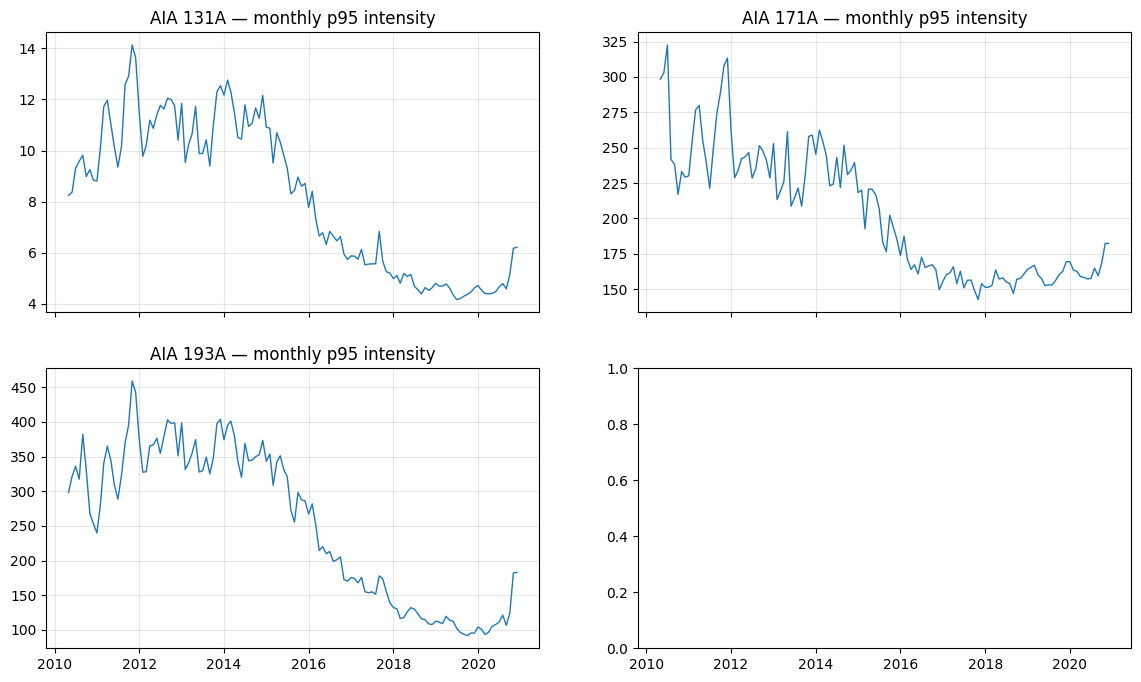

In [16]:
RUN_DEGRADATION_CHECK = True
degradation_correction: Dict[str, Dict[str, float]] = {ch: {} for ch in AIA_CHANNELS}

if RUN_DEGRADATION_CHECK:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    for ax, ch in zip(axes.flat, AIA_CHANNELS):
        parts = [monthly_p95(yr, ch) for yr in YEARS if ch in timestamps.get(yr, {})]
        if not parts:
            continue
        series = pd.concat(parts).sort_index()
        ax.plot(series.index, series.values, lw=1)
        ax.set_title(f"AIA {ch} — monthly p95 intensity"); ax.grid(alpha=0.3)

        # Linear trend on log-intensity: residual decline => per-year correction factor
        x = (series.index - series.index[0]).days.values.astype(float)
        y = np.log(np.clip(series.values, 1e-3, None))
        slope, intercept = np.polyfit(x[~np.isnan(y)], y[~np.isnan(y)], 1)
        trend_per_year = float(np.exp(slope * 365.25))
        if trend_per_year < 0.97:   # > 3%/yr systematic decline -> correct
            for i, yr in enumerate(YEARS):
                degradation_correction[ch][yr] = float(trend_per_year ** (-i))
            log.warning(f"AIA {ch}: residual degradation {100*(1-trend_per_year):.1f}%/yr "
                        f"-> per-year multiplicative correction stored")
        else:
            log.info(f"AIA {ch}: no significant residual degradation "
                     f"(trend {100*(1-trend_per_year):+.2f}%/yr) — SDOML correction OK")
    plt.tight_layout(); plt.show()

def degradation_factor(channel: str, year: str) -> float:
    """Multiplicative correction (1.0 when SDOML's own correction is sufficient)."""
    return degradation_correction.get(channel, {}).get(year, 1.0)

In [ ]:
# =====================================================================
# PHASE 5 — Derived feature computation functions
# =====================================================================
# Phase 5 — Derived Physical Features
# Computed after cleaning, before normalisation. The Jz / PIL-mask /
# 171Å-gradient maps are computed INTERNALLY only (the PIL mask feeds the
# per-frame scalar features below and the Phase 10 visual checks) — they are
# NOT stored as image channels. Stored channels = 7 raw (4 AIA + 3 HMI).
#
# | Feature                     | Source                                          | Type          |
# |-----------------------------|-------------------------------------------------|---------------|
# | Jz vertical current density | Bx, By central differences                      | internal map  |
# | PIL binary mask             | Bz zero-crossing, |B| > 150 G, 5-px dilation    | internal map  |
# | 171Å gradient magnitude     | |∇I₁₇₁|                                          | internal map  |
# | PIL length                  | count of PIL pixels                             | scalar/frame  |
# | Mean shear angle at PIL     | (Bx,By) vs PIL-perpendicular                    | scalar/frame  |
# | Unsigned flux Φ & ∂Φ/∂t    | Σ|Bz|·pixel_area, 12-min finite diff            | scalar series |

In [ ]:
# Step 5.1 — Vertical current density Jz = (dBy/dx - dBx/dy) / mu0
def compute_jz(bx: np.ndarray, by: np.ndarray, pixel_size_m: float = 0.504e6) -> np.ndarray:
    """
    Jz from central finite differences. Inputs must already be limb-masked
    (limb pixels create large spurious gradients).
    pixel_size_m: HMI plate scale ~0.504 Mm/px at 512 resolution (full disk / 512).
    """
    dby_dx = np.gradient(by, pixel_size_m, axis=1)
    dbx_dy = np.gradient(bx, pixel_size_m, axis=0)
    jz = (dby_dx - dbx_dy) / MU0
    return apply_limb_mask(jz).astype(np.float32)


# Step 5.2 — Polarity inversion line mask
def compute_pil_mask(bx: np.ndarray, by: np.ndarray, bz: np.ndarray
                     ) -> Tuple[np.ndarray, int]:
    """
    Binary PIL mask: Bz zero-crossing where |B_total| > 150 G, dilated 5 px.
    Returns (mask, pil_length_pixels).
    """
    b_total = np.sqrt(bx ** 2 + by ** 2 + bz ** 2)
    strong = b_total > PIL_BTOTAL_THRESH
    # Zero-crossing: sign change between 4-connected neighbours
    sign = np.sign(bz)
    zc = np.zeros_like(bz, dtype=bool)
    zc[:-1, :] |= (sign[:-1, :] * sign[1:, :]) < 0
    zc[:, :-1] |= (sign[:, :-1] * sign[:, 1:]) < 0
    pil_core = zc & strong & LIMB_MASK_512
    pil_len = int(pil_core.sum())
    mask = binary_dilation(pil_core, iterations=PIL_DILATE_PX)
    return mask.astype(np.float32), pil_len


# Step 5.3 — Mean magnetic shear angle along PIL
def compute_shear_angle(bx: np.ndarray, by: np.ndarray, pil_core_mask: np.ndarray) -> float:
    """
    Mean angle (deg) between observed horizontal field and the potential-field
    direction, approximated as perpendicular to the local PIL tangent.
    PIL tangent estimated from the gradient of the (smoothed) mask.
    """
    if pil_core_mask.sum() < 10:
        return 0.0
    gy, gx = np.gradient(pil_core_mask.astype(float))
    # gradient of mask points perpendicular to PIL -> potential direction proxy
    pot_x, pot_y = gx, gy
    norm_pot = np.hypot(pot_x, pot_y)
    norm_obs = np.hypot(bx, by)
    sel = (pil_core_mask > 0) & (norm_pot > 0) & (norm_obs > 0)
    if sel.sum() == 0:
        return 0.0
    cosang = np.clip(
        (bx[sel] * pot_x[sel] + by[sel] * pot_y[sel]) / (norm_obs[sel] * norm_pot[sel]),
        -1.0, 1.0)
    ang = np.degrees(np.arccos(np.abs(cosang)))    # fold to [0, 90]
    return float(np.mean(ang))


# Step 5.4 — Unsigned flux (per frame); emergence rate computed across frames later
def compute_unsigned_flux(bz: np.ndarray, pixel_area_cm2: float = (0.504e8) ** 2) -> float:
    """Phi = sum |Bz| * pixel_area  [Mx]; limb-masked input expected."""
    return float(np.sum(np.abs(bz)) * pixel_area_cm2)


# Step 5.5 — Coronal loop gradient map from AIA 171A
def compute_gradient_map(i171: np.ndarray) -> np.ndarray:
    """|grad I_171| — highlights loop boundaries and brightening fronts."""
    gy, gx = np.gradient(i171.astype(np.float32))
    return apply_limb_mask(np.hypot(gx, gy)).astype(np.float32)


print("Derived-feature functions ready: Jz, PIL mask, shear angle, unsigned flux, 171A gradient")

In [ ]:
# =====================================================================
# PHASE 5 + 8.5 - Frame assembly: cleaned 7-channel stack at 256x256
# =====================================================================
# Channel order (fixed contract for the whole project):
CHANNEL_ORDER = AIA_CHANNELS + HMI_CHANNELS   # 7 channels (4 AIA + 3 HMI), in this exact order
N_CHANNELS = len(CHANNEL_ORDER)


def downsample_area(frame: np.ndarray, factor: int = 512 // TARGET_SIZE) -> np.ndarray:
    """Area-average 512->256. Preserves integrated flux (NOT bilinear/bicubic)."""
    return downscale_local_mean(frame, (factor, factor)).astype(np.float32)


def fetch_raw_frame(year: str, channel: str, raw_idx: int) -> np.ndarray:
    """One raw 512x512 frame via the lazy Dask graph (reads only the owning chunk,
    served from the bounded LRU cache - never indexes the S3 zarr store directly)."""
    return np.asarray(lazy_store[year][channel][int(raw_idx)].compute()).astype(np.float32)


def fetch_raw_frames(year: str, channel: str, raw_indices) -> np.ndarray:
    """Fetch several frames of one channel through a SINGLE Dask graph / one compute.
    Overlapping zarr chunks are read once; returns an array in raw_indices order."""
    idx = np.asarray(raw_indices, dtype=np.int64)
    if idx.size == 0:
        return np.empty((0, 512, 512), dtype=np.float32)
    return np.asarray(lazy_store[year][channel][idx].compute()).astype(np.float32)


def _clean_and_correct(year: str, channel: str, frame: np.ndarray) -> Tuple[np.ndarray, float]:
    """Per-frame cleaning (cosmic ray + limb mask) plus AIA degradation correction."""
    frame, frac = clean_frame(frame)                         # Steps 4.1 + 4.5
    if channel in AIA_CHANNELS:
        frame = frame * degradation_factor(channel, year)    # Step 4.4
    return frame, frac


def assemble_from_cleaned(year: str, cleaned512: Dict[str, np.ndarray],
                          cr_fracs: Dict[str, float]) -> Tuple[np.ndarray, Dict[str, float]]:
    """Scalar features + 7-channel 256x256 stack from already-cleaned 512x512 raw channels."""
    bx, by, bz = cleaned512["Bx"], cleaned512["By"], cleaned512["Bz"]

    # PIL mask at native 512 resolution (Step 5.2) — computed INTERNALLY only,
    # to derive the per-frame scalar features below; it is NOT stored as a channel.
    pil_mask, pil_len = compute_pil_mask(bx, by, bz)

    # Scalar features (Steps 5.2-5.4)
    scalars = {
        "pil_length_px": pil_len,
        "shear_angle_deg": compute_shear_angle(bx, by, pil_mask),
        "unsigned_flux_Mx": compute_unsigned_flux(bz),
        "cr_frac_mean": float(np.mean(list(cr_fracs.values()))),
    }

    # Step 8.5 - area-average downsample the 7 raw channels to 256x256
    stack = np.stack(
        [downsample_area(cleaned512[ch]) for ch in RAW_CHANNELS],
        axis=0,
    )  # (7, 256, 256)
    return stack, scalars


def assemble_timestep(year: str, row: pd.Series) -> Tuple[np.ndarray, Dict[str, float]]:
    """
    Build the full 7-channel (256,256) physical-units stack for one aligned timestamp.
    Returns (stack[N_CHANNELS,256,256], scalar_features dict).
    Pipeline per plan: fetch -> cosmic-ray clean -> limb mask -> degradation
    correction (AIA) -> scalar features (at 512) -> area downsample to 256.
    """
    cleaned512: Dict[str, np.ndarray] = {}
    cr_fracs: Dict[str, float] = {}
    for ch in RAW_CHANNELS:
        idx = int(row[f"idx_{ch}"])
        if idx < 0:
            raise ValueError(f"assemble_timestep called on unmatched channel {ch}")
        frame, frac = _clean_and_correct(year, ch, fetch_raw_frame(year, ch, idx))
        cleaned512[ch] = frame
        cr_fracs[ch] = frac
    return assemble_from_cleaned(year, cleaned512, cr_fracs)


print(f"Channel contract ({N_CHANNELS}): {CHANNEL_ORDER}")


In [ ]:
# =====================================================================
# PHASE 6 / Steps 6.1–6.3 — Fit scalers on TRAINING SPLIT ONLY (2010–2014)
# =====================================================================
# Phase 6 — Normalisation
# All scaler statistics are computed on the training split only (2010–2014),
# on cleaned 256×256 physical-unit frames sampled across the train years.
#
# - AIA: arcsinh(x / a), a = 0.01 × train median, then z-score (train stats)
# - HMI: tanh(x / 1500 G), then z-score (train stats)
# - Scalars: shear ÷90 → [0,1] · flux rate: clip ±5σ, z-score
# - Optional: overwrite the 7 channel scalers with Surya-1.0 values for Models D & F

TRAIN_YEARS = [str(y) for y in range(SPLITS["train"][0], SPLITS["train"][1] + 1)]
SCALER_SAMPLE_PER_YEAR = 50          # aligned timestamps sampled per train year


def fit_scalers(sample_per_year: int = SCALER_SAMPLE_PER_YEAR) -> Dict[str, dict]:
    """
    Sample valid aligned timestamps uniformly across 2010–2014, assemble cleaned
    7-channel stacks, and fit per-channel scalers. Returns
      {channel: {kind, a?, b_sat?, clip?, mean, std}}
    """
    samples = {ch: [] for ch in CHANNEL_ORDER}
    flux_vals = []
    for yr in TRAIN_YEARS:
        t = align.get(yr)
        if t is None:
            continue
        valid_rows = t[t["valid"]]
        if len(valid_rows) == 0:
            continue
        pick = valid_rows.iloc[np.linspace(0, len(valid_rows) - 1,
                                           min(sample_per_year, len(valid_rows)),
                                           dtype=int)]
        prev_flux = None
        for _, row in tqdm(pick.iterrows(), total=len(pick), desc=f"scaler sample {yr}", leave=False):
            try:
                stack, scal = assemble_timestep(yr, row)
            except Exception as e:
                log.warning(f"scaler sample failed @ {row['time']}: {e}")
                continue
            for ci, ch in enumerate(CHANNEL_ORDER):
                samples[ch].append(stack[ci].ravel()[::37])      # sparse pixel sample
            if prev_flux is not None:
                flux_vals.append((scal["unsigned_flux_Mx"] - prev_flux) / (HMI_CADENCE_MIN * 60))
            prev_flux = scal["unsigned_flux_Mx"]

    scalers: Dict[str, dict] = {}
    for ch in CHANNEL_ORDER:
        x = np.concatenate(samples[ch]) if samples[ch] else np.array([0.0, 1.0])
        if ch in AIA_CHANNELS:
            # Step 6.1 — arcsinh stretch, a = train_median * 0.01
            a = max(float(np.median(x[x > 0])) * ARCSINH_A_FRAC, 1e-3)
            xs = np.arcsinh(x / a)
            scalers[ch] = {"kind": "arcsinh", "a": a,
                           "mean": float(xs.mean()), "std": float(xs.std() + 1e-8)}
        elif ch in HMI_CHANNELS:
            # Step 6.2 — tanh clip at B_sat = 1500 G
            xs = np.tanh(x / B_SAT)
            scalers[ch] = {"kind": "tanh", "b_sat": B_SAT,
                           "mean": float(xs.mean()), "std": float(xs.std() + 1e-8)}

    # Scalar: flux emergence rate (clip ±5σ, z-score)
    fr = np.array(flux_vals) if flux_vals else np.array([0.0, 1.0])
    mu, sd = float(fr.mean()), float(fr.std() + 1e-8)
    fr_c = np.clip(fr, mu - CLIP_SIGMA * sd, mu + CLIP_SIGMA * sd)
    scalers["flux_rate"] = {"kind": "clip_z", "clip": CLIP_SIGMA,
                            "mean": float(fr_c.mean()), "std": float(fr_c.std() + 1e-8)}
    # Scalar: shear angle -> [0,1] by /90
    scalers["shear_angle"] = {"kind": "div", "div": 90.0}
    return scalers


RUN_SCALER_FIT = True
if RUN_SCALER_FIT:
    scalers = fit_scalers()
    with open(os.path.join(OUT_DIR, "scalers.json"), "w") as f:
        json.dump(scalers, f, indent=2)
    print(json.dumps(scalers, indent=2)[:1500])
else:
    with open(os.path.join(OUT_DIR, "scalers.json")) as f:
        scalers = json.load(f)

In [ ]:
# =====================================================================
# PHASE 6 — Apply-normalisation function + Step 6.4 Surya scaler alignment
# =====================================================================
def normalise_stack(stack: np.ndarray, scaler_set: Dict[str, dict]) -> np.ndarray:
    """Apply per-channel normalisation to a (7, 256, 256) physical-units stack (float32)."""
    out = np.empty_like(stack, dtype=np.float32)
    for ci, ch in enumerate(CHANNEL_ORDER):
        s, x = scaler_set[ch], stack[ci]
        if s["kind"] == "arcsinh":
            x = np.arcsinh(x / s["a"]);            x = (x - s["mean"]) / s["std"]
        elif s["kind"] == "tanh":
            x = np.tanh(x / s["b_sat"]);           x = (x - s["mean"]) / s["std"]
        elif s["kind"] == "clip_z":
            lo = s["mean"] - s["clip"] * s["std"]; hi = s["mean"] + s["clip"] * s["std"]
            x = np.clip(x, lo, hi);                x = (x - s["mean"]) / s["std"]
        elif s["kind"] == "z":
            x = (x - s["mean"]) / s["std"]
        out[ci] = x
    return out

In [ ]:
# ---------------------------------------------------------------------
# Step 6.4 — Surya scaler alignment (Models D & F only)
# Overwrites the 7 channel scalers with Surya-1.0 values; the scalar-feature
# scalers (shear_angle, flux_rate) keep our own values (Surya has no equivalent).
# ---------------------------------------------------------------------
USE_SURYA_SCALERS = False     # set True when building inputs for Models D / F

if USE_SURYA_SCALERS:
    from huggingface_hub import hf_hub_download
    import yaml
    p = hf_hub_download(repo_id="nasa-ibm-ai4science/Surya-1.0", filename="scalers.yaml")
    with open(p) as f:
        surya = yaml.safe_load(f)
    # Map our channel names to Surya keys (e.g. '131A'->'aia131', 'Bz'->'hmi_bz')
    SURYA_KEY = {"131A": "aia131", "171A": "aia171", "193A": "aia193",
                 "1600A": "aia1600", "Bx": "hmi_bx", "By": "hmi_by", "Bz": "hmi_bz"}
    scalers_surya = dict(scalers)
    for ch, key in SURYA_KEY.items():
        if key in surya:
            scalers_surya[ch] = {**surya[key], "kind": surya[key].get("kind", "arcsinh")}
            log.info(f"{ch}: replaced with Surya scaler ({key})")
        else:
            log.warning(f"{ch}: '{key}' not found in Surya scalers.yaml — keeping own")
    with open(os.path.join(OUT_DIR, "scalers_surya.json"), "w") as f:
        json.dump(scalers_surya, f, indent=2)

print("Normalisation ready. Surya alignment:", "ON" if USE_SURYA_SCALERS else "OFF (own scalers)")

In [ ]:
# =====================================================================
# PHASE 7 / Step 7.1 — Fetch GOES flare catalog (M and X class, 2010–2020)
# =====================================================================
# Phase 7 — Label Generation
# - GOES flare catalog (primary for flares — more complete than DONKI): M/X events 2010–2020
# - DONKI CME catalog: fast CMEs (> 500 km/s) positive; slow CMEs flagged ambiguous (-1),
#   never negative
# - Confined-flare flag: flares with no DONKI CME within ±30 min
# - Per-horizon labels at t+6h / 12h / 24h / 48h, M and X kept separate throughout

# Uses the NOAA/SWPC-derived event lists. We query the HEK-backed sunpy
# Fido interface if available, else fall back to the NGDC plain-text lists.
def fetch_goes_flares() -> pd.DataFrame:
    """
    Returns DataFrame: [peak_time, start_time, class_letter, peak_flux, noaa_ar].
    Keeps only M- and X-class events (peak flux >= 1e-5 W/m²).
    """
    cache = os.path.join(OUT_DIR, "goes_flares_2010_2020.csv")
    if os.path.exists(cache):
        df = pd.read_csv(cache, parse_dates=["peak_time", "start_time"])
        log.info(f"GOES flares loaded from cache: {len(df)} events")
        return df

    from sunpy.net import Fido, attrs as a
    res = Fido.search(
        a.Time("2010-01-01", "2020-12-31"),
        a.hek.EventType("FL"),
        a.hek.FL.GOESCls >= "M1.0",
        a.hek.OBS.Observatory == "GOES",
    )
    tbl = res["hek"]

    def hek_time_to_str(col) -> list:
        """
        HEK time columns are astropy.time.Time objects — they have no .astype().
        Use .iso to get ISO-8601 strings, then let pandas parse them.
        Falls back to plain str() for any column that is already string-like.
        """
        try:
            return col.iso.tolist()          # astropy Time -> list of ISO strings
        except AttributeError:
            return [str(v) for v in col]    # already strings / other types
    
    df = pd.DataFrame({
        "peak_time": pd.to_datetime(hek_time_to_str(tbl["event_peaktime"])),
        "start_time": pd.to_datetime(hek_time_to_str(tbl["event_starttime"])),
        "goes_class": [str(c) for c in tbl["fl_goescls"]],
        "noaa_ar": [int(n) if str(n).isdigit() else -1 for n in tbl["ar_noaanum"]],
    })
    df["class_letter"] = df["goes_class"].str[0]
    mult = df["goes_class"].str[1:].replace("", "1.0").astype(float)
    df["peak_flux"] = np.where(df["class_letter"] == "X", 1e-4 * mult, 1e-5 * mult)
    df = df[df["class_letter"].isin(["M", "X"])].reset_index(drop=True)
    df.to_csv(cache, index=False)
    log.info(f"GOES flares fetched: {len(df)} M/X events")
    return df


flares = fetch_goes_flares()
print(flares["class_letter"].value_counts().to_string())
print(flares.head().to_string())

In [ ]:
# =====================================================================
# PHASE 7 / Step 7.2 — Fetch DONKI CME catalog (2010–2020)
# =====================================================================
def fetch_donki_cmes() -> pd.DataFrame:
    """
    Query NASA CCMC DONKI CMEAnalysis endpoint year-by-year.
    Returns DataFrame: [time, speed_kms, fast (bool), source_location, note].
    """
    cache = os.path.join(OUT_DIR, "donki_cmes_2010_2020.csv")
    if os.path.exists(cache):
        df = pd.read_csv(cache, parse_dates=["time"])
        log.info(f"DONKI CMEs loaded from cache: {len(df)} entries")
        return df

    rows = []
    for y in range(2010, 2021):
        url = ("https://kauai.ccmc.gsfc.nasa.gov/DONKI/WS/get/CMEAnalysis"
               f"?startDate={y}-01-01&endDate={y}-12-31&mostAccurateOnly=true")
        try:
            r = requests.get(url, timeout=120)
            r.raise_for_status()
            for item in (r.json() or []):
                spd = item.get("speed")
                t = item.get("time21_5")
                if spd is None or t is None:
                    continue
                rows.append({
                    "time": pd.to_datetime(t.replace("Z", "")),
                    "speed_kms": float(spd),
                    "source_location": item.get("sourceLocation", ""),
                    "lat": item.get("latitude"), "lon": item.get("longitude"),
                })
            log.info(f"DONKI {y}: {len(rows)} cumulative CME analyses")
        except Exception as e:
            log.error(f"DONKI {y} fetch failed: {e}")
    df = pd.DataFrame(rows)
    df["fast"] = df["speed_kms"] > CME_FAST_KMS
    df.to_csv(cache, index=False)
    return df


cmes = fetch_donki_cmes()
print(f"Total CME analyses: {len(cmes)} | fast (> {CME_FAST_KMS:.0f} km/s): {int(cmes['fast'].sum())}")

In [ ]:
# =====================================================================
# PHASE 7 / Step 7.4 — Identify and flag confined flares
# =====================================================================
# ~40% of M-class flares are confined (no associated CME). For every GOES
# flare, check DONKI for a CME within ±30 min of the flare peak.
CME_ASSOC_WINDOW = pd.Timedelta(minutes=30)

cme_times = pd.DatetimeIndex(cmes["time"]).sort_values()


def has_cme_association(peak_time: pd.Timestamp) -> bool:
    if len(cme_times) == 0:
        return False
    pos = cme_times.searchsorted(peak_time)
    for p in (pos - 1, pos):
        if 0 <= p < len(cme_times) and abs(cme_times[p] - peak_time) <= CME_ASSOC_WINDOW:
            return True
    return False


flares["confined_flag"] = [not has_cme_association(t) for t in flares["peak_time"]]
conf_rate = flares.groupby("class_letter")["confined_flag"].mean()
print("Confined fraction by class (expect ~0.4 for M):")
print(conf_rate.to_string())

In [ ]:
# =====================================================================
# PHASE 7 / Step 7.3 — Per-horizon label assignment function
# =====================================================================
flare_M_times = pd.DatetimeIndex(flares.loc[flares.class_letter == "M", "peak_time"]).sort_values()
flare_X_times = pd.DatetimeIndex(flares.loc[flares.class_letter == "X", "peak_time"]).sort_values()
fast_cme_times = pd.DatetimeIndex(cmes.loc[cmes["fast"], "time"]).sort_values()
slow_cme_times = pd.DatetimeIndex(cmes.loc[~cmes["fast"], "time"]).sort_values()


def any_in(times: pd.DatetimeIndex, t0: pd.Timestamp, t1: pd.Timestamp) -> bool:
    """True if any event time falls in (t0, t1]."""
    lo = times.searchsorted(t0, side="right")
    hi = times.searchsorted(t1, side="right")
    return hi > lo


def label_window(t_end: pd.Timestamp) -> Dict[str, int]:
    """
    Labels for a window whose input ends at t_end, checked independently per horizon.
    cme_flag: 1 = fast CME, 0 = nothing in DONKI, -1 = only slow CMEs (ambiguous,
              excluded from the negative class during training).
    """
    out = {}
    for h in FORECAST_HORIZONS_H:
        t1 = t_end + pd.Timedelta(hours=h)
        out[f"flare_M_{h}h"] = int(any_in(flare_M_times, t_end, t1))
        out[f"flare_X_{h}h"] = int(any_in(flare_X_times, t_end, t1))
        if any_in(fast_cme_times, t_end, t1):
            out[f"cme_{h}h"] = 1
        elif any_in(slow_cme_times, t_end, t1):
            out[f"cme_{h}h"] = -1          # ambiguous — NOT negative
        else:
            out[f"cme_{h}h"] = 0
    return out


print("Label functions ready.")
print("Example labels @ 2017-09-06 09:00 (X9.3 day):",
      label_window(pd.Timestamp("2017-09-06 09:00:00")))

In [ ]:
# DIAGNOSTIC — paste and run this
yr = "2010"
ts_bz, order_bz = timestamps[yr]["Bz"]
ts_131, order_131 = timestamps[yr]["131A"]

print("Bz dtype:", ts_bz.dtype)
print("131A dtype:", ts_131.dtype)
print("Bz sample:", ts_bz[:3])
print("131A sample:", ts_131[:3])

# Check what nearest_match actually returns for the first 5 anchors
m = nearest_match(ts_bz[:5], ts_131, AIA_MATCH_TOL)
print("nearest_match result:", m)

In [ ]:
# DIAGNOSTIC
print(dict(hmi_root["2010"]["Bz"].attrs).keys())

In [ ]:
# DIAGNOSTIC
print(type(hmi_root["2010"]["Bz"].attrs["T_OBS"]))
print(hmi_root["2010"]["Bz"].attrs["T_OBS"])
print(hmi_root["2010"]["Bz"].attrs["T_REC"])

In [ ]:
# =====================================================================
# PHASE 8 / Steps 8.1–8.4 + PHASE 9 / Step 9.1 — Build the window INDEX
# =====================================================================
# Phase 8 + 9 — Sliding Window Construction & Chronological Split
# - Input: 8 frames × 12 min = 96 min history → tensor (8, 7, 256, 256)
# - Horizons: t+6h / 12h / 24h / 48h, labelled independently
# - Stride: train 1 (12 min) · val 4 (48 min) · test 6 (72 min)
# - Validity: reject if > 1 invalid input frame or any unusable frame
# - Continuous sampling across the whole timeline — no pre-event-only selection
# - Split: train 2010–2014 · val 2015–2017 · test 2018–2020 (chronological, no leakage)
#
# The window index is built first (cheap, metadata only). Pixel data is then
# materialised shard-by-shard so the run can be resumed.

def year_split(year: str) -> str:
    y = int(year)
    for name, (lo, hi) in SPLITS.items():
        if lo <= y <= hi:
            return name
    raise ValueError(year)

# DIAGNOSTIC — run this before build_window_index()
for yr, t in align.items():
    print(yr, "| cols:", list(t.columns),
          "| fully_matched:", t["fully_matched"].sum(),
          "| valid:", t.get("valid", pd.Series(dtype=bool)).sum(),
          "| unusable:", t.get("unusable", pd.Series(dtype=bool)).sum(),
          "| interp_ok:", t.get("interp_ok", pd.Series(dtype=bool)).sum())
    break  # just check first year
    
    # This was giving error
# def build_window_index() -> pd.DataFrame:
#     """
#     One row per candidate window: (year, split, start row, end row, t_end, labels...).
#     Step 8.3 validity: reject if >1 input frame invalid OR any frame unusable.
#     Step 8.4: continuous sampling — every stride position is a candidate.
#     """
#     rows = []
#     for yr, t in align.items():
#         split = year_split(yr)
#         stride = STRIDE[split]
#         n = len(t)
#         unusable = t["unusable"].values
#         invalid = ~t["valid"].values            # invalid = needs interp or unusable
#         kept = dropped = 0
#         for s in range(0, n - T_IN + 1, stride):
#             e = s + T_IN                         # input rows [s, e)
#             win_unusable = unusable[s:e].any()
#             win_invalid_ct = int(invalid[s:e].sum())
#             if win_unusable or win_invalid_ct > 1:
#                 dropped += 1
#                 continue
#             t_end = t["time"].iloc[e - 1]
#             rec = {"year": yr, "split": split, "row_start": s, "row_end": e,
#                    "t_end": t_end, "n_interp": win_invalid_ct}
#             rec.update(label_window(t_end))      # Phase 7 labels per horizon
#             rows.append(rec)
#             kept += 1
#         log.info(f"{yr} [{split}]: windows kept={kept}, rejected={dropped}")
#     return pd.DataFrame(rows)

def build_window_index() -> pd.DataFrame:
    rows = []
    for yr, t in align.items():
        split = year_split(yr)
        stride = STRIDE[split]
        n = len(t)
        unusable   = t["unusable"].values
        interp_gap = t["interp_ok"].values          # recoverable single-frame gaps
        kept = dropped = 0
        for s in range(0, n - T_IN + 1, stride):
            e = s + T_IN
            # Hard reject: any frame is completely unusable
            if unusable[s:e].any():
                dropped += 1
                continue
            # Soft reject: more than 1 interpolable gap in the window
            n_interp = int(interp_gap[s:e].sum())
            if n_interp > 1:
                dropped += 1
                continue
            t_end = t["time"].iloc[e - 1]
            rec = {"year": yr, "split": split, "row_start": s, "row_end": e,
                   "t_end": t_end, "n_interp": n_interp}
            rec.update(label_window(t_end))
            rows.append(rec)
            kept += 1
        log.info(f"{yr} [{split}]: windows kept={kept}, rejected={dropped}")
    return pd.DataFrame(rows)


window_index = build_window_index()
window_index.to_parquet(os.path.join(OUT_DIR, "window_index.parquet"))
print(f"\nTotal windows: {len(window_index)}")
# print(window_index.groupby("split").size().to_string())
if len(window_index) == 0:
    print("WARNING: no windows built — check diagnostic output above")
else:
    print(window_index.groupby("split").size().to_string())

In [ ]:
# =====================================================================
# PHASE 8 - Materialise window tensors (shard-by-shard, resumable)
# =====================================================================
# Each shard = SHARD_SIZE windows saved as one compressed .npz:
#   X        (N, 8, 7, 256, 256) float16  - normalised input tensors (7 raw channels)
#   scalars  (N, 8, 3)           float16  - [pil_length, shear/90, flux_rate_z] per step
#   labels   (N, 12)             int8     - [M,X,CME] x [6,12,24,48]h
#   t_end    (N,)                datetime64
# Normalisation is computed in float32; X and scalars are downcast to float16
# ONCE, at the end of materialise_window(), immediately before shard writing.
SHARD_SIZE = 64
LABEL_COLS = ([f"flare_M_{h}h" for h in FORECAST_HORIZONS_H]
            + [f"flare_X_{h}h" for h in FORECAST_HORIZONS_H]
            + [f"cme_{h}h" for h in FORECAST_HORIZONS_H])

active_scalers = scalers   # or scalers_surya when USE_SURYA_SCALERS


def norm_scalar(name: str, v: float) -> float:
    s = active_scalers[name]
    if s["kind"] == "div":
        return v / s["div"]
    lo = s["mean"] - s["clip"] * s["std"]; hi = s["mean"] + s["clip"] * s["std"]
    return (np.clip(v, lo, hi) - s["mean"]) / s["std"]


def materialise_window(rec: pd.Series) -> Tuple[np.ndarray, np.ndarray]:
    """Assemble + normalise one window. Returns (X[8,7,256,256] float16, scalars[8,3] float16).

    All physics and normalisation math is done in float32; the float16 cast is
    applied once at the end, purely as a storage dtype.

    Every raw frame the window needs is pulled through the lazy Dask graph in ONE
    compute per channel (overlapping zarr chunks read once, shared frames cleaned
    once) instead of one S3 read per (frame, channel)."""
    yr, t = rec["year"], align[rec["year"]]
    seq = list(range(rec["row_start"], rec["row_end"]))

    # Per timestep: how to build it, and which raw frame indices each channel needs.
    # valid row -> its own frame; isolated gap -> mean of the two flanking frames.
    plan = []                                   # ("direct", r) | ("interp", r-1, r+1)
    need = {ch: set() for ch in RAW_CHANNELS}
    for r in seq:
        if t.iloc[r]["valid"]:
            plan.append(("direct", r))
            src_rows = (r,)
        else:
            plan.append(("interp", r - 1, r + 1))
            src_rows = (r - 1, r + 1)
        for rr in src_rows:
            for ch in RAW_CHANNELS:
                need[ch].add(int(t.iloc[rr][f"idx_{ch}"]))

    # One Dask compute per channel for every frame this window touches; clean once.
    cleaned: Dict[str, Dict[int, np.ndarray]] = {ch: {} for ch in RAW_CHANNELS}
    cr_frac: Dict[str, Dict[int, float]] = {ch: {} for ch in RAW_CHANNELS}
    for ch in RAW_CHANNELS:
        idxs = sorted(i for i in need[ch] if i >= 0)
        frames = fetch_raw_frames(yr, ch, idxs)
        for k, raw_i in enumerate(idxs):
            fr, frac = _clean_and_correct(yr, ch, frames[k])
            cleaned[ch][raw_i] = fr
            cr_frac[ch][raw_i] = frac

    def stack_for_row(r: int) -> Tuple[np.ndarray, Dict[str, float]]:
        c512 = {ch: cleaned[ch][int(t.iloc[r][f"idx_{ch}"])] for ch in RAW_CHANNELS}
        crf = {ch: cr_frac[ch][int(t.iloc[r][f"idx_{ch}"])] for ch in RAW_CHANNELS}
        return assemble_from_cleaned(yr, c512, crf)

    stacks, scals, prev_flux = [], [], None
    for item in plan:
        if item[0] == "direct":
            stack, sc = stack_for_row(item[1])
        else:
            s_prev, _ = stack_for_row(item[1])
            s_next, sc = stack_for_row(item[2])
            stack = 0.5 * (s_prev + s_next)
        flux_rate = (0.0 if prev_flux is None
                     else (sc["unsigned_flux_Mx"] - prev_flux) / (HMI_CADENCE_MIN * 60))
        prev_flux = sc["unsigned_flux_Mx"]
        stacks.append(normalise_stack(stack, active_scalers))
        scals.append([sc["pil_length_px"],
                      norm_scalar("shear_angle", sc["shear_angle_deg"]),
                      norm_scalar("flux_rate", flux_rate)])
    # Storage dtype cast: normalisation above ran in float32; downcast ONCE here.
    X = np.stack(stacks).astype(np.float16)
    S = np.array(scals, dtype=np.float32).astype(np.float16)
    return X, S


def write_shards(split: str, max_shards: Optional[int] = None):
    """Materialise all windows of a split into resumable .npz shards."""
    sub = window_index[window_index["split"] == split].reset_index(drop=True)
    shard_dir = os.path.join(OUT_DIR, split)
    os.makedirs(shard_dir, exist_ok=True)
    n_shards = int(np.ceil(len(sub) / SHARD_SIZE))
    for si in range(n_shards):
        if max_shards is not None and si >= max_shards:
            log.info(f"{split}: stopping after {max_shards} shard(s) (demo limit)")
            break
        path = os.path.join(shard_dir, f"shard_{si:05d}.npz")
        if os.path.exists(path):
            continue                                          # resumable
        chunk = sub.iloc[si * SHARD_SIZE:(si + 1) * SHARD_SIZE]
        Xs, Ss, Ls, Ts = [], [], [], []
        for _, rec in tqdm(chunk.iterrows(), total=len(chunk),
                           desc=f"{split} shard {si}", leave=False):
            try:
                X, S = materialise_window(rec)
            except Exception as e:
                log.warning(f"window @ {rec['t_end']} failed: {e}")
                continue
            Xs.append(X); Ss.append(S)
            Ls.append(rec[LABEL_COLS].values.astype(np.int8))
            Ts.append(np.datetime64(rec["t_end"]))
        if Xs:
            np.savez_compressed(path, X=np.stack(Xs), scalars=np.stack(Ss),
                                labels=np.stack(Ls), t_end=np.array(Ts))
            log.info(f"wrote {path} ({len(Xs)} windows)")


# DEMO: build 1 shard per split to validate the pipeline end-to-end.
# PRODUCTION: call write_shards(split) with max_shards=None (long-running, network-bound).
for split_name in ["train", "val", "test"]:
    write_shards(split_name, max_shards=2)


In [ ]:
# =====================================================================
# PHASE 9 / Steps 9.2–9.4 — Leakage checks & class-rate documentation
# =====================================================================

# Step 9.2 — Normalisation leakage check: scalers were fit on TRAIN_YEARS only.
# Report per-channel mean/std shift of val and test under TRAIN scalers.
def normalisation_shift_report(sample_per_year: int = 10):
    rows = []
    for split in ["val", "test"]:
        yrs = [str(y) for y in range(SPLITS[split][0], SPLITS[split][1] + 1)]
        for ch in CHANNEL_ORDER:
            vals = []
            for yr in yrs:
                t = align.get(yr)
                if t is None:
                    continue
                vr = t[t["valid"]]
                pick = vr.iloc[np.linspace(0, len(vr) - 1,
                                           min(sample_per_year, len(vr)), dtype=int)]
                for _, row in pick.iterrows():
                    try:
                        stack, _ = assemble_timestep(yr, row)
                        x = normalise_stack(stack, active_scalers)[CHANNEL_ORDER.index(ch)]
                        vals.append([x.mean(), x.std()])
                    except Exception:
                        continue
            if vals:
                v = np.array(vals)
                rows.append({"split": split, "channel": ch,
                             "mean_shift": round(float(v[:, 0].mean()), 3),
                             "std_ratio": round(float(v[:, 1].mean()), 3)})
    return pd.DataFrame(rows)


RUN_SHIFT_CHECK = False    # network-heavy; enable for production audit
if RUN_SHIFT_CHECK:
    shift_df = normalisation_shift_report()
    print("Normalised mean should be ~0, std ~1. Larger shifts expected for "
          "activity-sensitive channels (131A) near solar minimum:")
    print(shift_df.to_string())

# Step 9.3 — hyperparameter policy (documented, enforced at training time):
print("POLICY: hyperparameter tuning on VAL only; TEST touched once per model.\n")

# Step 9.4 — class rates per split (Solar-Cycle differences are expected)
rate_rows = []
for split in ["train", "val", "test"]:
    sub = window_index[window_index["split"] == split]
    n = max(len(sub), 1)
    rate_rows.append({
        "split": split, "windows": len(sub),
        "M_rate_24h_%": round(100 * (sub["flare_M_24h"] == 1).mean(), 3),
        "X_rate_24h_%": round(100 * (sub["flare_X_24h"] == 1).mean(), 3),
        "fastCME_rate_24h_%": round(100 * (sub["cme_24h"] == 1).mean(), 3),
        "ambiguousCME_24h_%": round(100 * (sub["cme_24h"] == -1).mean(), 3),
    })
class_rates = pd.DataFrame(rate_rows).set_index("split")
print(class_rates.to_string())
class_rates.to_csv(os.path.join(OUT_DIR, "class_rates_per_split.csv"))

In [ ]:
# =====================================================================
# PHASE 10 / Step 10.1 — Label sanity on known major events
# =====================================================================
# Phase 10 — Dataset Validation Checks
# Run BEFORE training: label sanity on known X-class events, class-balance audit,
# temporal autocorrelation of labels, and visual verification of Jz / PIL maps.

KNOWN_EVENTS = [
    ("2017-09-06 11:53", "X", "X9.3 — 6 Sep 2017"),
    ("2017-09-10 16:06", "X", "X8.2 — 10 Sep 2017"),
    ("2011-02-15 01:56", "X", "X2.2 — 15 Feb 2011 (first X of Cycle 24)"),
]

for t_str, cls, name in KNOWN_EVENTS:
    t_evt = pd.Timestamp(t_str)
    # a window ending 6h before the event must carry flare_X_6h = 1
    lab = label_window(t_evt - pd.Timedelta(hours=3))
    ok = lab[f"flare_{cls}_6h"] == 1
    print(f"[{'PASS' if ok else 'FAIL'}] {name}: window@t-3h -> flare_{cls}_6h = {lab[f'flare_{cls}_6h']}")

# Spot-check positive windows (visual inspection of 131A + Bz)
pos = window_index[window_index["flare_M_24h"] == 1]
if len(pos) > 0:
    spot = pos.sample(min(5, len(pos)), random_state=42)
    print(f"\nSpot-check sample ({len(spot)} positive M-flare windows):")
    print(spot[["year", "t_end", "flare_M_24h", "flare_X_24h", "cme_24h"]].to_string())


In [ ]:
# =====================================================================
# PHASE 10 / Steps 10.2 + 10.3 — Class balance audit & label autocorrelation
# =====================================================================

# Step 10.2 — expected: M ~1-3% of 24h windows, X ~0.1-0.3%, fast CME ~0.5-1.5%
audit = {
    "M_24h_%": 100 * (window_index["flare_M_24h"] == 1).mean(),
    "X_24h_%": 100 * (window_index["flare_X_24h"] == 1).mean(),
    "fastCME_24h_%": 100 * (window_index["cme_24h"] == 1).mean(),
}
print("=== Class balance audit (full dataset) ===")
for k, v in audit.items():
    print(f"  {k}: {v:.3f}")
if audit["M_24h_%"] > 5:
    log.warning("M-flare rate suspiciously high — check for pre-event-only sampling bias!")

# Step 10.3 — temporal autocorrelation of flare_M_24h (train split, stride 1)
train_lbl = window_index[window_index["split"] == "train"].sort_values("t_end")
y = (train_lbl["flare_M_24h"] == 1).astype(float).values
if len(y) > 500:
    y = y - y.mean()
    max_lag = 400
    ac = np.array([np.corrcoef(y[:-k], y[k:])[0, 1] if k > 0 else 1.0
                   for k in range(max_lag)])
    plt.figure(figsize=(10, 3.5))
    plt.plot(ac, lw=1)
    plt.axvline(200, color="r", ls="--", label="lag 200 (~40 h) — should be ≈0 beyond")
    plt.axhline(0, color="k", lw=0.5)
    plt.title("Autocorrelation of flare_M_24h label (train, stride 1)")
    plt.xlabel("lag (windows)"); plt.ylabel("ACF"); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f"ACF @ lag 200: {ac[200]:.4f} (should be near zero)")
else:
    print("Not enough train windows for the autocorrelation check (demo run).")

In [ ]:
# =====================================================================
# PHASE 10 / Step 10.5 — Visual verification of Jz and PIL maps
# =====================================================================
# Plot Jz map and PIL mask overlaid on HMI Bz for one active period and one
# quiet period. PIL should align with Bz zero-crossings in strong-field regions;
# Jz should concentrate along PILs in active regions, near-zero elsewhere.
def verify_jz_pil(year: str, when: str, title: str):
    t = align.get(year)
    if t is None or not t["valid"].any():
        print(f"{year}: no valid timestamps"); return
    target = pd.Timestamp(when)
    vr = t[t["valid"]]
    row = vr.iloc[(vr["time"] - target).abs().argmin()]
    bz = apply_limb_mask(fetch_raw_frame(year, "Bz", int(row["idx_Bz"])))
    bx = apply_limb_mask(fetch_raw_frame(year, "Bx", int(row["idx_Bx"])))
    by = apply_limb_mask(fetch_raw_frame(year, "By", int(row["idx_By"])))
    jz = compute_jz(bx, by)
    pil, plen = compute_pil_mask(bx, by, bz)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
    v = np.nanpercentile(np.abs(bz), 99) or 1
    axes[0].imshow(bz, origin="lower", cmap="RdBu_r", vmin=-v, vmax=v)
    axes[0].set_title(f"HMI Bz — {row['time']}")
    jv = np.nanpercentile(np.abs(jz), 99) or 1
    axes[1].imshow(jz, origin="lower", cmap="PuOr_r", vmin=-jv, vmax=jv)
    axes[1].set_title("Jz (vertical current density)")
    axes[2].imshow(bz, origin="lower", cmap="RdBu_r", vmin=-v, vmax=v)
    axes[2].contour(pil, levels=[0.5], colors="lime", linewidths=0.8)
    axes[2].set_title(f"PIL mask overlay (length = {plen}px)")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()


# Flare-productive: AR 12673 (Sep 2017); quiet: solar minimum (2019)
verify_jz_pil("2017", "2017-09-06 09:00", "ACTIVE — AR 12673, X9.3 flare day")
verify_jz_pil("2019", "2019-06-15 12:00", "QUIET — solar minimum")

In [ ]:
# =====================================================================
# Output Summary & Production Run Checklist
# =====================================================================
#
# Dataset artefacts written to ./sdoml_dataset_out/:
#   coverage_stats.csv              — Phase 3 alignment coverage per year
#   scalers.json (+ scalers_surya.json) — Phase 6 normalisation parameters (train-split only)
#   goes_flares_2010_2020.csv       — Phase 7 GOES flare label catalog
#   donki_cmes_2010_2020.csv        — Phase 7 DONKI CME label catalog
#   window_index.parquet            — every candidate window with per-horizon labels
#   class_rates_per_split.csv       — Phase 9.4 documentation
#   train/, val/, test/             — .npz shards: X (N,8,7,256,256) float16,
#                                     scalars (N,8,3) float16, labels (N,12) int8,
#                                     t_end (N,) datetime64
#
# For the full production run, flip these switches and re-run top-to-bottom:
#   1. RUN_DISAMBIG_SCAN = True     — full HMI disambiguation jump scan (Step 4.3)
#   2. RUN_SHIFT_CHECK = True       — normalisation shift audit (Step 9.2)
#   3. write_shards(split, max_shards=None) — materialise ALL windows
#      (network-bound; resumable, so it can be interrupted and restarted safely)
#   4. Optionally USE_SURYA_SCALERS = True for Model D / F input variants
#
# Remaining manual checks (Phase 10): Step 10.4 (active-region longitude distribution
# via NOAA SRS daily files) requires the SRS archive and is left as a follow-up audit script.
